# Nettoyage des données — Projet Data Warehouse Films

**Datasets :**
- `tmdb_5000_movies.csv` — budget, revenus, genres, langue
- `tmdb_5000_credits.csv` — réalisateur, casting

**Source :** https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata

In [1]:
import pandas as pd
import ast
import re
import missingno as msno
import matplotlib.pyplot as plt

In [2]:
# Chargement des deux fichiers CSV
movies_df  = pd.read_csv('tmdb_5000_movies.csv')
credits_df = pd.read_csv('tmdb_5000_credits.csv')

print('Forme du fichier movies :', movies_df.shape)
print('Forme du fichier credits:', credits_df.shape)

Forme du fichier movies : (4803, 20)
Forme du fichier credits: (4803, 4)


In [3]:
# Apercu du fichier movies
print(movies_df.head(10))

      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
3  250000000  [{"id": 28, "name": "Action"}, {"id": 80, "nam...   
4  260000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
5  258000000  [{"id": 14, "name": "Fantasy"}, {"id": 28, "na...   
6  260000000  [{"id": 16, "name": "Animation"}, {"id": 10751...   
7  280000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
8  250000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
9  250000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                            homepage      id  \
0                        http://www.avatarmovie.com/   19995   
1       http://disney.go.com/disneypictures/pirates/     285   
2        http://www.sonypictures.com/movies/spectre/  206647   
3     

In [4]:
# Apercu du fichier credits
print(credits_df.head(10))

   movie_id                                     title  \
0     19995                                    Avatar   
1       285  Pirates of the Caribbean: At World's End   
2    206647                                   Spectre   
3     49026                     The Dark Knight Rises   
4     49529                               John Carter   
5       559                              Spider-Man 3   
6     38757                                   Tangled   
7     99861                   Avengers: Age of Ultron   
8       767    Harry Potter and the Half-Blood Prince   
9    209112        Batman v Superman: Dawn of Justice   

                                                cast  \
0  [{"cast_id": 242, "character": "Jake Sully", "...   
1  [{"cast_id": 4, "character": "Captain Jack Spa...   
2  [{"cast_id": 1, "character": "James Bond", "cr...   
3  [{"cast_id": 2, "character": "Bruce Wayne / Ba...   
4  [{"cast_id": 5, "character": "John Carter", "c...   
5  [{"cast_id": 30, "character": "Pe

In [5]:
# Informations generales sur le fichier movies
movies_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   str    
 10  production_countries  4803 non-null   str    
 11  release_date          4802 non-null   str    
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   str    
 15  status                4803 non-n

In [6]:
# Informations generales sur le fichier credits
credits_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   movie_id  4803 non-null   int64
 1   title     4803 non-null   str  
 2   cast      4803 non-null   str  
 3   crew      4803 non-null   str  
dtypes: int64(1), str(3)
memory usage: 150.2 KB


## 1. Fusion des deux datasets

Les deux fichiers partagent la colonne `id` (movies) et `movie_id` (credits). On les fusionne pour avoir un seul dataframe complet.

In [7]:
# Renommer 'movie_id' en 'id' dans credits si necessaire
if 'movie_id' in credits_df.columns:
    credits_df.rename(columns={'movie_id': 'id'}, inplace=True)

# Fusion sur la colonne 'id'
df = movies_df.merge(credits_df[['id', 'cast', 'crew']], on='id', how='left')
print('Forme apres fusion :', df.shape)

Forme apres fusion : (4803, 22)


## 2. Detection des valeurs manquantes

In [8]:
# Afficher True/False pour chaque cellule
valeurs_manquantes = df.isnull()
print(valeurs_manquantes)

      budget  genres  homepage     id  keywords  original_language  \
0      False   False     False  False     False              False   
1      False   False     False  False     False              False   
2      False   False     False  False     False              False   
3      False   False     False  False     False              False   
4      False   False     False  False     False              False   
...      ...     ...       ...    ...       ...                ...   
4798   False   False      True  False     False              False   
4799   False   False      True  False     False              False   
4800   False   False     False  False     False              False   
4801   False   False     False  False     False              False   
4802   False   False      True  False     False              False   

      original_title  overview  popularity  production_companies  ...  \
0              False     False       False                 False  ...   
1            

In [9]:
# Compter les valeurs manquantes par colonne
valeurs_manquantes = df.isnull().sum()
print(valeurs_manquantes)

budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
cast                       0
crew                       0
dtype: int64


In [10]:
# Pourcentage de valeurs manquantes par colonne
pct_manquantes = (df.isnull().sum() / len(df) * 100).round(2)
print(pct_manquantes)

budget                   0.00
genres                   0.00
homepage                64.36
id                       0.00
keywords                 0.00
original_language        0.00
original_title           0.00
overview                 0.06
popularity               0.00
production_companies     0.00
production_countries     0.00
release_date             0.02
revenue                  0.00
runtime                  0.04
spoken_languages         0.00
status                   0.00
tagline                 17.57
title                    0.00
vote_average             0.00
vote_count               0.00
cast                     0.00
crew                     0.00
dtype: float64


In [11]:
# Compter les valeurs non-nulles par colonne
valeurs_presentes = df.notnull().sum()
print(valeurs_presentes)

budget                  4803
genres                  4803
homepage                1712
id                      4803
keywords                4803
original_language       4803
original_title          4803
overview                4800
popularity              4803
production_companies    4803
production_countries    4803
release_date            4802
revenue                 4803
runtime                 4801
spoken_languages        4803
status                  4803
tagline                 3959
title                   4803
vote_average            4803
vote_count              4803
cast                    4803
crew                    4803
dtype: int64


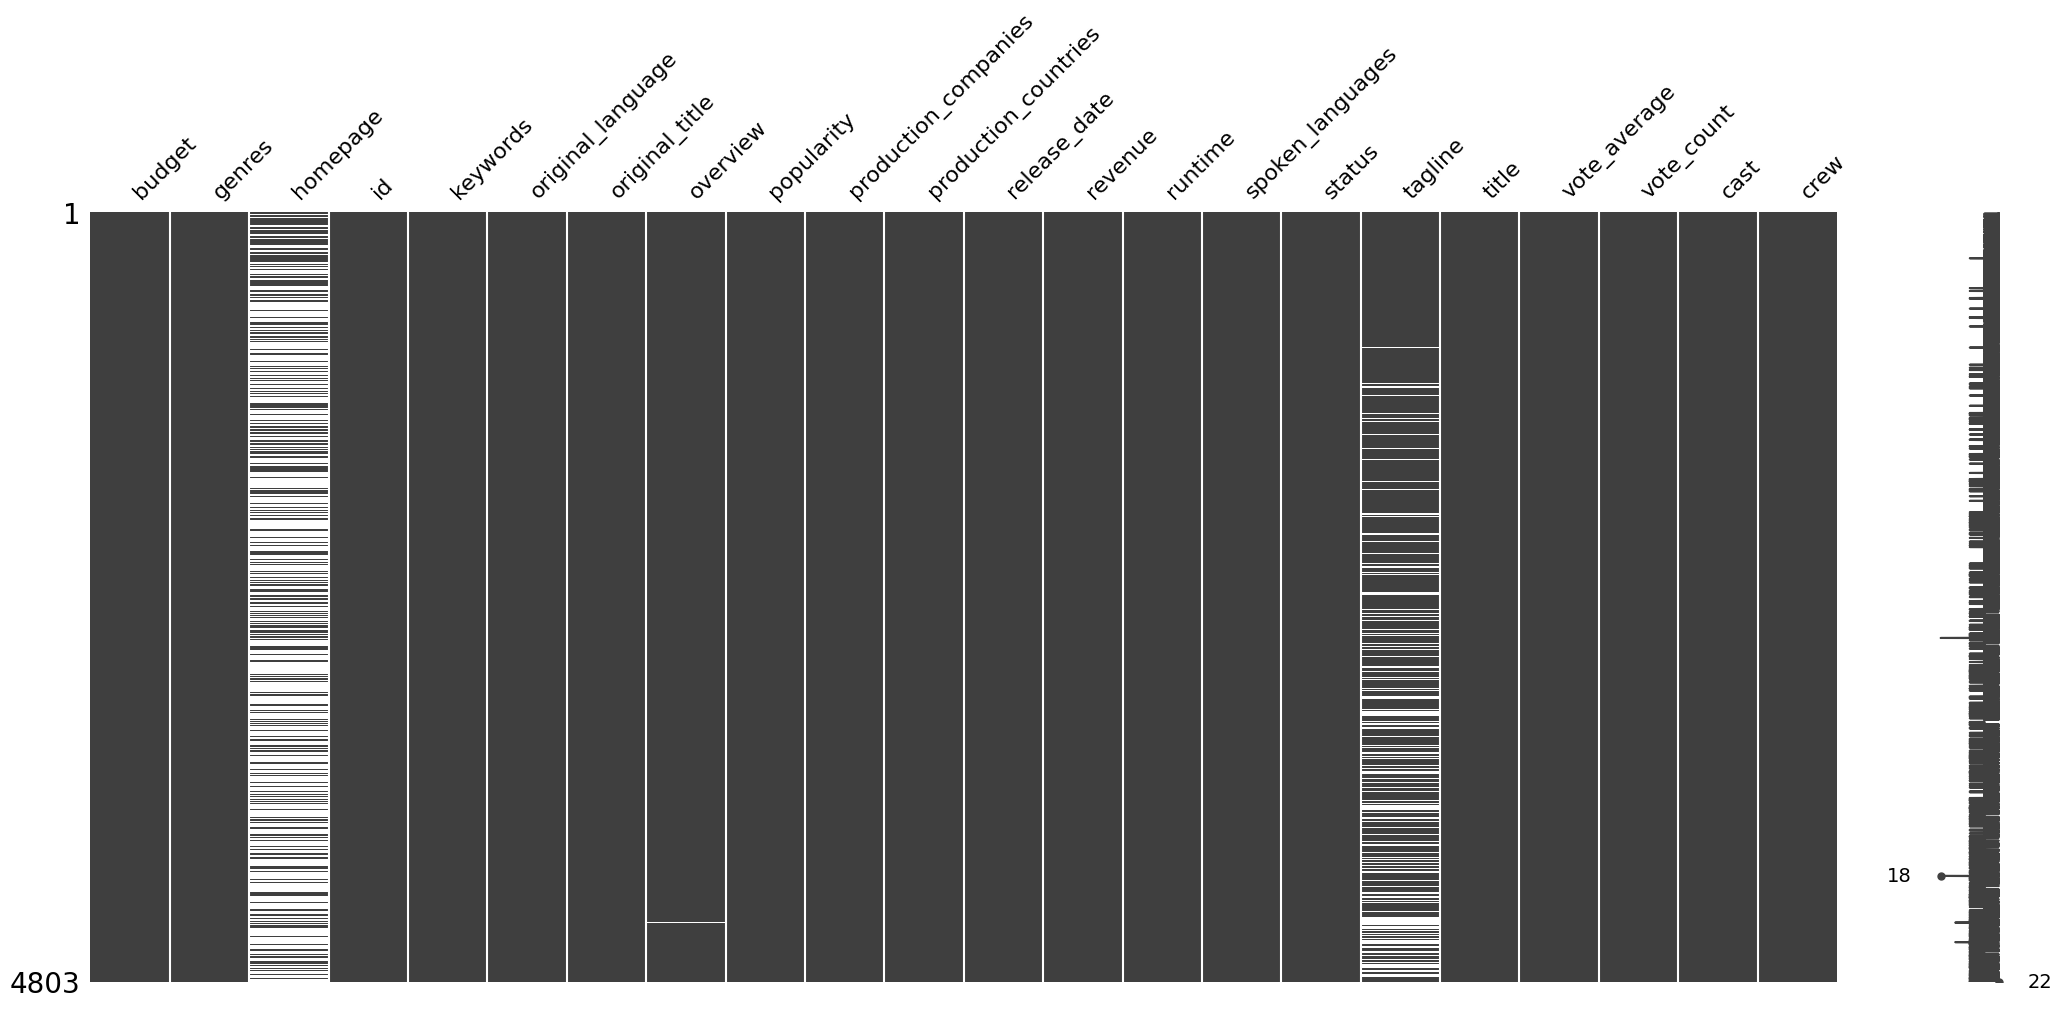

In [12]:
# Visualisation graphique des valeurs manquantes
msno.matrix(df)
plt.show()

## 3. Traitement des valeurs manquantes

In [13]:
# Supprimer les lignes sans titre, date de sortie, budget ou revenus
# Ce sont des colonnes indispensables pour nos tables de faits
avant = len(df)
df.dropna(subset=['title', 'release_date', 'budget', 'revenue'], inplace=True)
print(f'Lignes supprimees (valeurs critiques manquantes) : {avant - len(df)}')
print(f'Lignes restantes : {len(df)}')

Lignes supprimees (valeurs critiques manquantes) : 1
Lignes restantes : 4802


In [14]:
# Remplacer les valeurs manquantes de 'runtime' par la mediane
mediane_runtime = df['runtime'].median()
df['runtime'].fillna(mediane_runtime, inplace=True)
print(f'Runtime mediane utilisee pour remplacement : {mediane_runtime}')

Runtime mediane utilisee pour remplacement : 103.0


C:\Users\Hala\AppData\Local\Temp\ipykernel_59328\226132145.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['runtime'].fillna(mediane_runtime, inplace=True)


In [48]:
# Remplacer les valeurs manquantes de 'homepage' et 'tagline' par chaine vide
df['homepage'] = df['homepage'].fillna('')
df['tagline']  = df['tagline'].fillna('')
print('Valeurs manquantes apres traitement :')
print(df.isnull().sum())

Valeurs manquantes apres traitement :
budget                  0
genres                  0
homepage                0
id                      0
keywords                0
original_language       0
original_title          0
overview                0
popularity              0
production_companies    0
production_countries    0
release_date            0
revenue                 0
runtime                 0
spoken_languages        0
status                  0
tagline                 0
title                   0
vote_average            0
vote_count              0
cast                    0
crew                    0
genres_parsed           0
primary_genre           0
all_genres              0
companies_parsed        0
studio_name             0
studio_country          0
countries_parsed        0
primary_country         0
languages_parsed        0
primary_language        0
director                0
top_cast                0
release_year            0
release_month           0
release_quarter         0


## 4. Detection et suppression des doublons

In [16]:
# Detecter les doublons exacts (toutes colonnes)
doublons = df.duplicated()
print(doublons)

0       False
1       False
2       False
3       False
4       False
        ...  
4798    False
4799    False
4800    False
4801    False
4802    False
Length: 4802, dtype: bool


In [17]:
# Compter le nombre total de doublons exacts
nb_doublons = df.duplicated().sum()
print(f'Nombre de doublons exacts : {nb_doublons}')

Nombre de doublons exacts : 0


In [18]:
# Detecter les doublons sur titre + date de sortie (meme film, IDs differents)
doublons_titre = df.duplicated(subset=['title', 'release_date'], keep=False)
print('Lignes dupliquees (meme titre + meme date) :')
print(df[doublons_titre][['id', 'title', 'release_date', 'budget', 'revenue']])

Lignes dupliquees (meme titre + meme date) :
Empty DataFrame
Columns: [id, title, release_date, budget, revenue]
Index: []


In [19]:
# Supprimer les doublons — garder la premiere occurrence
avant = len(df)
df.drop_duplicates(subset=['id'], inplace=True)
print(f'Lignes supprimees (doublons sur id) : {avant - len(df)}')
print(f'Lignes restantes : {len(df)}')

Lignes supprimees (doublons sur id) : 0
Lignes restantes : 4802


## 5. Detection des valeurs aberrantes

In [20]:
# Valeurs aberrantes : budget ou revenus egaux a zero
# Un film avec budget=0 ou revenue=0 n'a pas de donnees financieres reelles
budget_zero = df[(df['budget'] == 0) | (df['revenue'] == 0)]
print(f'Films avec budget ou revenus nuls : {len(budget_zero)}')
print(budget_zero[['title', 'budget', 'revenue']].head(10))

Films avec budget ou revenus nuls : 1573
                                      title     budget    revenue
83                               The Lovers   27000000          0
135                             The Wolfman  150000000          0
265                      The Cat in the Hat          0          0
309                         Son of the Mask   84000000          0
321                            The Campaign          0  104907746
359  Alvin and the Chipmunks: The Road Chip          0  233755553
376                                 Volcano   90000000          0
406                        Arthur Christmas          0          0
409                           All That Jazz          0   37823676
433                                   RED 2   84000000          0


In [21]:
# Supprimer les films sans donnees financieres
avant = len(df)
df = df[(df['budget'] > 0) & (df['revenue'] > 0)]
print(f'Lignes supprimees (budget/revenue nuls) : {avant - len(df)}')
print(f'Lignes restantes : {len(df)}')

Lignes supprimees (budget/revenue nuls) : 1573
Lignes restantes : 3229


In [22]:
# Valeurs aberrantes : duree (runtime) irrealiste
# Un film ne peut pas durer moins de 40 min ou plus de 400 min
runtime_aberrant = df[(df['runtime'] < 40) | (df['runtime'] > 400)]
print('Films avec duree aberrante :')
print(runtime_aberrant[['title', 'runtime']])

Films avec duree aberrante :
Empty DataFrame
Columns: [title, runtime]
Index: []


In [23]:
# Supprimer les films avec duree aberrante
avant = len(df)
df = df[(df['runtime'] >= 40) & (df['runtime'] <= 400)]
print(f'Lignes supprimees (runtime aberrant) : {avant - len(df)}')

Lignes supprimees (runtime aberrant) : 0


In [24]:
# Valeurs aberrantes : budget au-dela du 99eme percentile
seuil_budget  = df['budget'].quantile(0.99)
seuil_revenue = df['revenue'].quantile(0.99)
print(f'Seuil budget  (99e percentile) : {seuil_budget:,.0f} $')
print(f'Seuil revenue (99e percentile) : {seuil_revenue:,.0f} $')

aberrants_budget = df[df['budget'] > seuil_budget]
print(f'\nFilms avec budget aberrant : {len(aberrants_budget)}')
print(aberrants_budget[['title', 'budget', 'revenue']])

Seuil budget  (99e percentile) : 200,000,000 $
Seuil revenue (99e percentile) : 920,026,852 $

Films avec budget aberrant : 27
                                          title     budget     revenue
0                                        Avatar  237000000  2787965087
1      Pirates of the Caribbean: At World's End  300000000   961000000
2                                       Spectre  245000000   880674609
3                         The Dark Knight Rises  250000000  1084939099
4                                   John Carter  260000000   284139100
5                                  Spider-Man 3  258000000   890871626
6                                       Tangled  260000000   591794936
7                       Avengers: Age of Ultron  280000000  1405403694
8        Harry Potter and the Half-Blood Prince  250000000   933959197
9            Batman v Superman: Dawn of Justice  250000000   873260194
10                             Superman Returns  270000000   391081192
13                   

In [25]:
# Supprimer les outliers extremes
avant = len(df)
df = df[(df['budget'] <= seuil_budget) & (df['revenue'] <= seuil_revenue)]
print(f'Lignes supprimees (outliers budget/revenue) : {avant - len(df)}')
print(f'Lignes restantes : {len(df)}')

Lignes supprimees (outliers budget/revenue) : 48
Lignes restantes : 3181


## 6. Parsing des colonnes JSON

Dans ce dataset, les colonnes `genres`, `production_companies`, etc. sont stockees sous forme de chaines JSON. On les convertit en vraies listes Python.

In [26]:
# Fonction utilitaire pour parser une chaine JSON en liste Python
def safe_parse(valeur):
    try:
        return ast.literal_eval(valeur)
    except (ValueError, SyntaxError):
        return []

# Avant parsing — afficher la valeur brute
print('Valeur brute de genres (ligne 0) :')
print(movies_df['genres'].iloc[0])

Valeur brute de genres (ligne 0) :
[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]


In [27]:
# Parser les genres — extraire le genre principal et tous les genres
df['genres_parsed']  = df['genres'].apply(safe_parse)
df['primary_genre']  = df['genres_parsed'].apply(
    lambda lst: lst[0]['name'] if lst else 'Unknown'
)
df['all_genres'] = df['genres_parsed'].apply(
    lambda lst: ', '.join([g['name'] for g in lst])
)
print(df[['title', 'primary_genre', 'all_genres']].head(10))

                                  title    primary_genre  \
11                    Quantum of Solace        Adventure   
21                           Robin Hood           Action   
23                   The Golden Compass        Adventure   
30                         Spider-Man 2           Action   
34                  Monsters University        Animation   
35  Transformers: Revenge of the Fallen  Science Fiction   
37           Oz: The Great and Powerful          Fantasy   
38             The Amazing Spider-Man 2           Action   
39                         TRON: Legacy        Adventure   
40                               Cars 2        Animation   

                              all_genres  
11    Adventure, Action, Thriller, Crime  
21                     Action, Adventure  
23                    Adventure, Fantasy  
30            Action, Adventure, Fantasy  
34                     Animation, Family  
35    Science Fiction, Action, Adventure  
37            Fantasy, Adventure, Fami

In [28]:
# Parser les societes de production — extraire le studio principal
df['companies_parsed'] = df['production_companies'].apply(safe_parse)
df['studio_name']      = df['companies_parsed'].apply(
    lambda lst: lst[0]['name'] if lst else 'Unknown'
)
df['studio_country']   = df['companies_parsed'].apply(
    lambda lst: lst[0].get('origin_country', 'Unknown') if lst else 'Unknown'
)
print(df[['title', 'studio_name', 'studio_country']].head(10))

                                  title            studio_name studio_country
11                    Quantum of Solace        Eon Productions        Unknown
21                           Robin Hood  Imagine Entertainment        Unknown
23                   The Golden Compass        New Line Cinema        Unknown
30                         Spider-Man 2      Columbia Pictures        Unknown
34                  Monsters University   Walt Disney Pictures        Unknown
35  Transformers: Revenge of the Fallen     Paramount Pictures        Unknown
37           Oz: The Great and Powerful   Walt Disney Pictures        Unknown
38             The Amazing Spider-Man 2      Columbia Pictures        Unknown
39                         TRON: Legacy   Walt Disney Pictures        Unknown
40                               Cars 2   Walt Disney Pictures        Unknown


In [29]:
# Parser les pays de production
df['countries_parsed'] = df['production_countries'].apply(safe_parse)
df['primary_country']  = df['countries_parsed'].apply(
    lambda lst: lst[0]['name'] if lst else 'Unknown'
)
print(df[['title', 'primary_country']].head(10))

                                  title           primary_country
11                    Quantum of Solace            United Kingdom
21                           Robin Hood            United Kingdom
23                   The Golden Compass            United Kingdom
30                         Spider-Man 2  United States of America
34                  Monsters University  United States of America
35  Transformers: Revenge of the Fallen  United States of America
37           Oz: The Great and Powerful  United States of America
38             The Amazing Spider-Man 2  United States of America
39                         TRON: Legacy  United States of America
40                               Cars 2  United States of America


In [30]:
# Parser les langues parlees
df['languages_parsed'] = df['spoken_languages'].apply(safe_parse)
df['primary_language'] = df['languages_parsed'].apply(
    lambda lst: lst[0].get('english_name', lst[0].get('name', 'Unknown')) if lst else 'Unknown'
)
print(df[['title', 'primary_language', 'original_language']].head(10))

                                  title primary_language original_language
11                    Quantum of Solace          English                en
21                           Robin Hood          English                en
23                   The Golden Compass         Íslenska                en
30                         Spider-Man 2          English                en
34                  Monsters University          English                en
35  Transformers: Revenge of the Fallen          English                en
37           Oz: The Great and Powerful          English                en
38             The Amazing Spider-Man 2          English                en
39                         TRON: Legacy          English                en
40                               Cars 2          English                en


## 7. Extraction du realisateur et du casting

La colonne `crew` contient tous les membres de l'equipe. On filtre ceux dont `job == 'Director'`.

In [31]:
# Extraire le realisateur depuis la colonne crew
def get_director(crew_str):
    crew = safe_parse(crew_str)
    directeurs = [m['name'] for m in crew if m.get('job') == 'Director']
    return directeurs[0] if directeurs else 'Unknown'

df['director'] = df['crew'].apply(get_director)
print(df[['title', 'director']].head(10))

                                  title         director
11                    Quantum of Solace     Marc Forster
21                           Robin Hood     Ridley Scott
23                   The Golden Compass      Chris Weitz
30                         Spider-Man 2        Sam Raimi
34                  Monsters University      Dan Scanlon
35  Transformers: Revenge of the Fallen      Michael Bay
37           Oz: The Great and Powerful        Sam Raimi
38             The Amazing Spider-Man 2        Marc Webb
39                         TRON: Legacy  Joseph Kosinski
40                               Cars 2    John Lasseter


In [32]:
# Extraire les 3 premiers acteurs du casting
def get_top_cast(cast_str, n=3):
    cast = safe_parse(cast_str)
    return ', '.join([m['name'] for m in cast[:n]])

df['top_cast'] = df['cast'].apply(get_top_cast)
print(df[['title', 'top_cast']].head(10))

                                  title  \
11                    Quantum of Solace   
21                           Robin Hood   
23                   The Golden Compass   
30                         Spider-Man 2   
34                  Monsters University   
35  Transformers: Revenge of the Fallen   
37           Oz: The Great and Powerful   
38             The Amazing Spider-Man 2   
39                         TRON: Legacy   
40                               Cars 2   

                                             top_cast  
11      Daniel Craig, Olga Kurylenko, Mathieu Amalric  
21       Russell Crowe, Cate Blanchett, Max von Sydow  
23  Dakota Blue Richards, Nicole Kidman, Daniel Craig  
30         Tobey Maguire, Kirsten Dunst, James Franco  
34         Billy Crystal, John Goodman, Steve Buscemi  
35              Shia LaBeouf, Megan Fox, Josh Duhamel  
37             James Franco, Mila Kunis, Rachel Weisz  
38            Andrew Garfield, Emma Stone, Jamie Foxx  
39        Garrett Hedl

## 8. Correction des types de donnees

In [33]:
# Convertir release_date en type datetime
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

# Supprimer les lignes ou la conversion a echoue
avant = len(df)
df.dropna(subset=['release_date'], inplace=True)
print(f'Lignes supprimees (date invalide) : {avant - len(df)}')
print(df['release_date'].dtype)

Lignes supprimees (date invalide) : 0
datetime64[us]


In [34]:
# Deriver les attributs de date pour la table dim_date
df['release_year']    = df['release_date'].dt.year
df['release_month']   = df['release_date'].dt.month
df['release_quarter'] = df['release_date'].dt.quarter
df['release_day']     = df['release_date'].dt.day
df['release_week']    = df['release_date'].dt.isocalendar().week.astype(int)

print(df[['title', 'release_date', 'release_year', 'release_month', 'release_quarter']].head(10))

                                  title release_date  release_year  \
11                    Quantum of Solace   2008-10-30          2008   
21                           Robin Hood   2010-05-12          2010   
23                   The Golden Compass   2007-12-04          2007   
30                         Spider-Man 2   2004-06-25          2004   
34                  Monsters University   2013-06-20          2013   
35  Transformers: Revenge of the Fallen   2009-06-19          2009   
37           Oz: The Great and Powerful   2013-03-07          2013   
38             The Amazing Spider-Man 2   2014-04-16          2014   
39                         TRON: Legacy   2010-12-10          2010   
40                               Cars 2   2011-06-11          2011   

    release_month  release_quarter  
11             10                4  
21              5                2  
23             12                4  
30              6                2  
34              6                2  
35     

In [35]:
# Ajouter la saison de sortie
def get_season(month):
    if month in [12, 1, 2]:   return 'Hiver'
    elif month in [3, 4, 5]:  return 'Printemps'
    elif month in [6, 7, 8]:  return 'Ete'
    else:                     return 'Automne'

df['release_season'] = df['release_month'].apply(get_season)
print(df[['title', 'release_month', 'release_season']].head(10))

                                  title  release_month release_season
11                    Quantum of Solace             10        Automne
21                           Robin Hood              5      Printemps
23                   The Golden Compass             12          Hiver
30                         Spider-Man 2              6            Ete
34                  Monsters University              6            Ete
35  Transformers: Revenge of the Fallen              6            Ete
37           Oz: The Great and Powerful              3      Printemps
38             The Amazing Spider-Man 2              4      Printemps
39                         TRON: Legacy             12          Hiver
40                               Cars 2              6            Ete


In [36]:
# Forcer les colonnes numeriques au bon type
for col in ['budget', 'revenue', 'runtime', 'vote_average', 'vote_count', 'popularity']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Types apres conversion :')
print(df[['budget', 'revenue', 'runtime', 'vote_average', 'vote_count']].dtypes)

Types apres conversion :
budget            int64
revenue           int64
runtime         float64
vote_average    float64
vote_count        int64
dtype: object


In [37]:
# Normaliser la colonne original_language en majuscules
df['original_language'] = df['original_language'].str.upper()
print(df['original_language'].value_counts().head(10))

original_language
EN    3054
FR      25
ES      15
JA      13
ZH      13
DE       9
HI       7
RU       6
IT       6
KO       5
Name: count, dtype: int64


In [38]:
# Nettoyer les noms de studios (supprimer les caracteres speciaux)
df['studio_name'] = df['studio_name'].apply(
    lambda x: re.sub(r'[^\w\s\-\.]', '', str(x)).strip()
)
print(df['studio_name'].value_counts().head(10))

studio_name
Paramount Pictures                        237
Universal Pictures                        223
Columbia Pictures                         162
Twentieth Century Fox Film Corporation    158
New Line Cinema                           135
Walt Disney Pictures                       86
Village Roadshow Pictures                  64
Miramax Films                              61
United Artists                             61
Columbia Pictures Corporation              58
Name: count, dtype: int64


## 9. Calcul des indicateurs cles (KPI)

Ces colonnes seront chargees directement dans la table `fact_box_office`.

In [39]:
# Profit = revenus - budget
df['profit'] = df['revenue'] - df['budget']
print(df[['title', 'budget', 'revenue', 'profit']].head(10))

                                  title     budget    revenue     profit
11                    Quantum of Solace  200000000  586090727  386090727
21                           Robin Hood  200000000  310669540  110669540
23                   The Golden Compass  180000000  372234864  192234864
30                         Spider-Man 2  200000000  783766341  583766341
34                  Monsters University  200000000  743559607  543559607
35  Transformers: Revenge of the Fallen  150000000  836297228  686297228
37           Oz: The Great and Powerful  200000000  491868548  291868548
38             The Amazing Spider-Man 2  200000000  705717432  505717432
39                         TRON: Legacy  170000000  400062763  230062763
40                               Cars 2  200000000  559852396  359852396


In [40]:
# ROI = (revenus - budget) / budget
df['roi'] = ((df['revenue'] - df['budget']) / df['budget']).round(4)
print(df[['title', 'budget', 'revenue', 'roi']].head(10))

                                  title     budget    revenue     roi
11                    Quantum of Solace  200000000  586090727  1.9305
21                           Robin Hood  200000000  310669540  0.5533
23                   The Golden Compass  180000000  372234864  1.0680
30                         Spider-Man 2  200000000  783766341  2.9188
34                  Monsters University  200000000  743559607  2.7178
35  Transformers: Revenge of the Fallen  150000000  836297228  4.5753
37           Oz: The Great and Powerful  200000000  491868548  1.4593
38             The Amazing Spider-Man 2  200000000  705717432  2.5286
39                         TRON: Legacy  170000000  400062763  1.3533
40                               Cars 2  200000000  559852396  1.7993


In [42]:
# Colonne booleenne : le film est-il rentable ?
df['is_profit'] = df['profit'] > 0
print(f"Films rentables    : {df['is_profit'].sum()}")
print(f"Films non rentables: {(~df['is_profit']).sum()}")

Films rentables    : 2391
Films non rentables: 790


In [43]:
# Categorie de revenus pour regroupement dans les tableaux de bord
def revenue_tier(rev):
    if rev >= 500_000_000:   return 'Blockbuster (500M+)'
    elif rev >= 100_000_000: return 'Hit (100M-500M)'
    elif rev >= 10_000_000:  return 'Mid-range (10M-100M)'
    else:                    return 'Faible (< 10M)'

df['revenue_tier'] = df['revenue'].apply(revenue_tier)
print(df['revenue_tier'].value_counts())

revenue_tier
Mid-range (10M-100M)    1548
Hit (100M-500M)          973
Faible (< 10M)           556
Blockbuster (500M+)      104
Name: count, dtype: int64


## 10. Selection des colonnes finales et sauvegarde

In [44]:
# Selectionner uniquement les colonnes utiles pour l'ETL
final_df = df[[
    'id',               'title',            'original_title',
    'director',         'primary_genre',     'all_genres',
    'original_language','primary_language',  'runtime',
    'top_cast',         'overview',
    'studio_name',      'studio_country',    'primary_country',
    'release_date',     'release_year',      'release_month',
    'release_quarter',  'release_day',       'release_week',
    'release_season',
    'budget',           'revenue',           'profit',
    'roi',              'is_profit',         'revenue_tier',
    'vote_average',     'vote_count',        'popularity',
]].copy()

final_df.rename(columns={'id': 'tmdb_id', 'vote_average': 'user_score'}, inplace=True)
print('Forme finale :', final_df.shape)

Forme finale : (3181, 30)


In [45]:
# Verification finale des valeurs manquantes
print('Valeurs manquantes dans le dataset final :')
print(final_df.isnull().sum()[final_df.isnull().sum() > 0])

Valeurs manquantes dans le dataset final :
Series([], dtype: int64)


In [46]:
# Apercu final
print(final_df[['title', 'director', 'primary_genre', 'revenue', 'profit', 'roi']].head(10))

                                  title         director    primary_genre  \
11                    Quantum of Solace     Marc Forster        Adventure   
21                           Robin Hood     Ridley Scott           Action   
23                   The Golden Compass      Chris Weitz        Adventure   
30                         Spider-Man 2        Sam Raimi           Action   
34                  Monsters University      Dan Scanlon        Animation   
35  Transformers: Revenge of the Fallen      Michael Bay  Science Fiction   
37           Oz: The Great and Powerful        Sam Raimi          Fantasy   
38             The Amazing Spider-Man 2        Marc Webb           Action   
39                         TRON: Legacy  Joseph Kosinski        Adventure   
40                               Cars 2    John Lasseter        Animation   

      revenue     profit     roi  
11  586090727  386090727  1.9305  
21  310669540  110669540  0.5533  
23  372234864  192234864  1.0680  
30  78376634

In [47]:
# Sauvegarde du dataset nettoye
final_df.to_csv('cleaned_movies.csv', index=False)
print('Dataset nettoye sauvegarde => cleaned_movies.csv')

Dataset nettoye sauvegarde => cleaned_movies.csv
